# **Две задачи на сравнение центров распределений**

Ожидается, что Вы правильно поставите задачу и проверите статистическую гипотезу правильно выбранным критерием. Кроме того, решение должны быть проиллюстрировано ящиковой диаграммой.


# **Задача 1**
Данные находятся в папке Nursing Home Data

Описание переменных:

BED = число коек в больнице

MCDAYS = annual medical in-patient days (hundreds)

TDAYS = annual total patient days (hundreds)

PCREV = получено от пациентов за год ( в сотнях долларов)

NSAL = годовой оклад медсестры (в сотнях долларов)

FEXP = расходы больницы за год (сотни долларов)

RURAL = код типа больницы: загородная (код 1) или городская (код 0)

Нужно сравнить показатели для больниц расположенных за городом и в городе. А именно расходы больницы за год (сотни долларов) (2 вариант).

**Гипотезы:**
- **$H_0$:** Медианные значения годовых расходов городских и загородных больниц равны.
- **$H_1$:** Медианные значения годовых расходов статистически значимо различаются.

Уровень значимости: α = 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


df_nursing = pd.read_csv('Nursing Home Data_data.txt', sep=r'\s+',  skipinitialspace=True)
df_nursing.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [2]:
# Разделение на группы
rural_fexp = df_nursing[df_nursing['RURAL'] == 1]['FEXP']
urban_fexp = df_nursing[df_nursing['RURAL'] == 0]['FEXP']

print(f"Количество загородных больниц: {len(rural_fexp)}")
print(f"Количество городских больниц: {len(urban_fexp)}")

Количество загородных больниц: 34
Количество городских больниц: 18


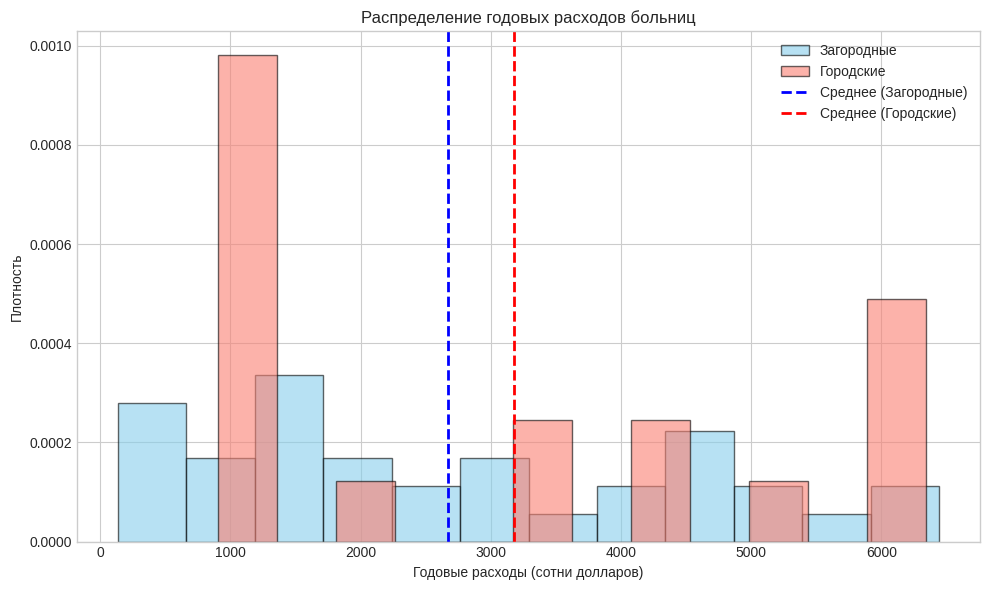

In [3]:
def plot_double_hist(data1, data2, label1, label2, xlabel, title):
    plt.figure(figsize=(10, 6))
    plt.hist(data1, bins=12, alpha=0.6, density=True, label=label1, color='skyblue', edgecolor='black')
    plt.hist(data2, bins=12, alpha=0.6, density=True, label=label2, color='salmon', edgecolor='black')
    plt.axvline(data1.mean(), color='blue', linestyle='--', linewidth=2, label=f'Среднее ({label1})')
    plt.axvline(data2.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее ({label2})')
    plt.xlabel(xlabel)
    plt.ylabel('Плотность')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_double_hist(
    rural_fexp, urban_fexp,
    'Загородные', 'Городские',
    'Годовые расходы (сотни долларов)',
    'Распределение годовых расходов больниц'
)


Тест Шапиро-Уилка:

In [4]:

shapiro_rural = stats.shapiro(rural_fexp)
print('Для загородных больниц p-value: ', shapiro_rural[1])

shapiro_urban = stats.shapiro(urban_fexp)
print('Для городских больниц p-value: ', shapiro_urban[1])

Для загородных больниц p-value:  0.04017793201644618
Для городских больниц p-value:  0.003969292378007504


В обоих случаях значение p-value меньше 0.05, то есть распеределения не являются нормальными (по гистограмме это тоже можно увидеть).

Следовательно, мы проверяем гипотезу о равенстве медиан через критерий Манна-Уитни.

In [30]:

u_stat, p_value = stats.mannwhitneyu(rural_fexp, urban_fexp, alternative='two-sided')

print("\nРезультаты критерия Манна-Уитни:")
print(f"  U-статистика: {u_stat:.2f}")
print(f"  p-значение:   {p_value:.4f}")
print(f"  Медиана (загородные): {rural_fexp.median():.1f}")
print(f"  Медиана (городские):  {urban_fexp.median():.1f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nВывод: p-value ({p_value:.4f}) < {alpha} → Отвергаем H₀.")
    print("Статистически значимые различия в расходах между группами обнаружены.")
else:
    print(f"\nВывод: p-value ({p_value:.4f}) >= {alpha} → Нет оснований отвергнуть H₀.")
    print("Статистически значимых различий в расходах между группами не обнаружено.")



Результаты критерия Манна-Уитни:
  U-статистика: 273.00
  p-значение:   0.5319
  Медиана (загородные): 2377.5
  Медиана (городские):  2737.0

Вывод: p-value (0.5319) >= 0.05 → Нет оснований отвергнуть H₀.
Статистически значимых различий в расходах между группами не обнаружено.


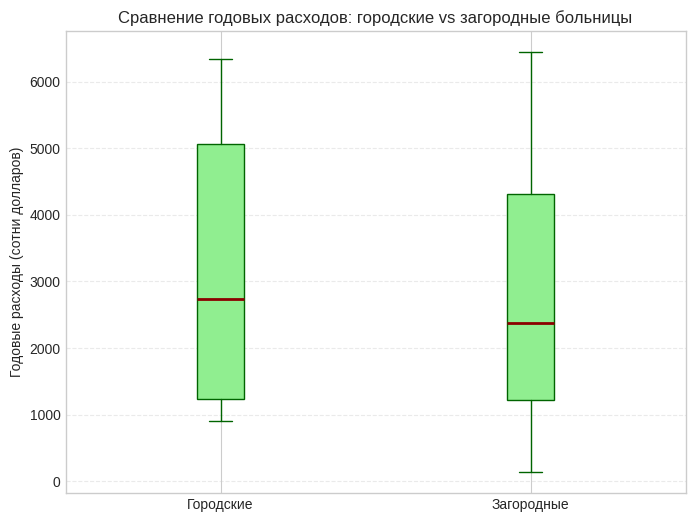

In [79]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(
    [urban_fexp, rural_fexp],
    patch_artist=True,
    tick_labels=['Городские', 'Загородные'],
    boxprops=dict(facecolor='lightgreen', color='darkgreen'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen'),
    medianprops=dict(color='darkred', linewidth=2)
)
plt.title('Сравнение годовых расходов: городские vs загородные больницы')
plt.ylabel('Годовые расходы (сотни долларов)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


На графике видно, что медиана городских больниц немного выше, но разброс данных (ящики) сильно перекрываются, что объясняет, почему p-value > 0.05 и различия не являются статистически значимыми.

## Задача 2. Влияние закона "Right-to-Work" на профсоюзную плотность

### 2.1. Описание данных и постановка задачи

**Набор данных:** Unions and State Labor Law

**Переменные:**
- DENS — доля госслужащих — членов профсоюзов (в %)
- RTW — наличие закона "Right-to-Work": 1 — закон принят, 0 — не принят

**Цель исследования:** Оценить, влияет ли наличие закона "Right-to-Work" на уровень профсоюзной плотности среди государственных служащих.

**Гипотезы:**
- **$H_0$:** Средние доли членов профсоюзов в штатах с законом и без него не различаются.
- **$H_1$:** Средние доли статистически значимо различаются.

Уровень значимости: α = 0.05

In [11]:
# Загрузка данных (разделитель — табуляция)
df_unions = pd.read_csv('Unions and State Labor Law_data.txt', sep=r'\s+',  skipinitialspace=True)

print("Первые 5 строк датасета:")
display(df_unions.head())

# Разделение по признаку RTW
dens_no_rtw = df_unions[df_unions['RTW'] == 0]['DENS']
dens_has_rtw = df_unions[df_unions['RTW'] == 1]['DENS']

print(f"Штатов без закона RTW: {len(dens_no_rtw)}")
print(f"Штатов с законом RTW:  {len(dens_has_rtw)}")

Первые 5 строк датасета:


,STATE,DENS,COMP,RTW,PVT
0,NY,56.9,1,0,31.2
1,MI,49.6,1,0,30.2
2,WA,32.4,1,0,33.1
3,HI,54.6,1,0,24.7
4,AK,30.7,1,0,30.1


Штатов без закона RTW: 30
Штатов с законом RTW:  20


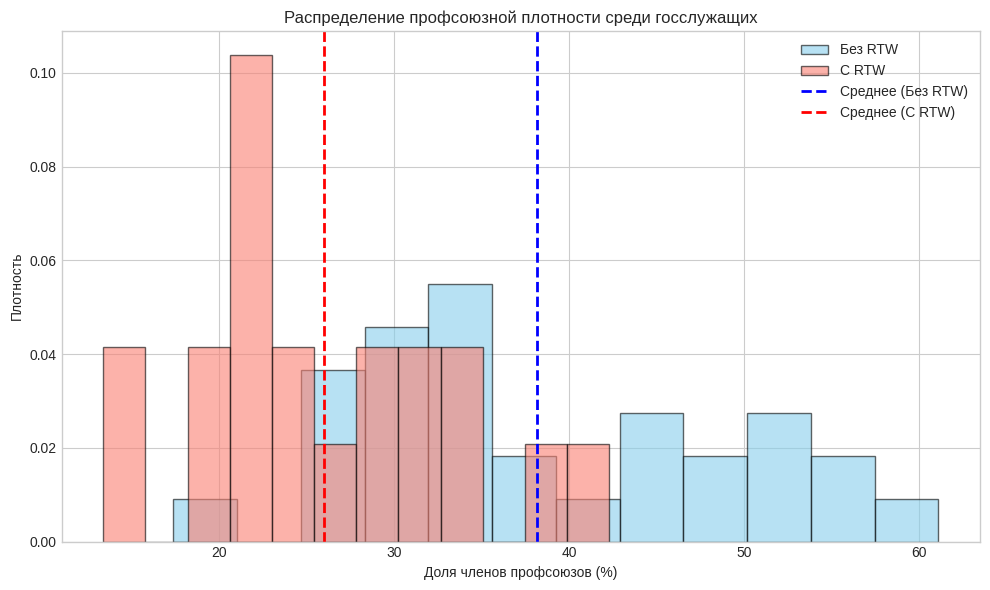

In [12]:
plot_double_hist(
    dens_no_rtw, dens_has_rtw,
    'Без RTW', 'С RTW',
    'Доля членов профсоюзов (%)',
    'Распределение профсоюзной плотности среди госслужащих'
)

In [28]:
# Тест Шапиро-Уилка, Проверка нормальности
shapiro_no_rtw = stats.shapiro(dens_no_rtw)
shapiro_has_rtw = stats.shapiro(dens_has_rtw)


print("Результаты проверки на нормальность:")
print(f"p-value = {shapiro_no_rtw.pvalue:.4f}")
print(f"p-value = {shapiro_has_rtw.pvalue:.4f}")


Результаты проверки на нормальность:
p-value = 0.1917
p-value = 0.6464


В обоих случаях значение p-value больше 0.05, то есть распеределения являются близкими к нормальныму.

Следовательно, дальше надо проверить равны ли дисперсии:

In [25]:
disp_res = stats.fligner(dens_no_rtw, dens_has_rtw)
print('p-value: ', disp_res[1])

p-value:  0.12569758439648204


p-value больше уровня значимости 0.05 => принимаем гипотезу о равенстве дисперсий.

В этих выборках находятся независимые объекты, поэтому гипотезу о равенстве средних проверяем через критерий Стьюдента для независимых выборок.

In [26]:

res = stats.ttest_ind(dens_no_rtw, dens_has_rtw, equal_var=True)
print('p-value: ', res[1])



p-value:  9.287017631717846e-05


Значение p-value меньше 0.05, следовательно мы отвергаем нулевую гипотезу. Различия в проценте членов профсоюзов между группами статистически значимы, а значит закон влияет на желание служащих вступать в профсоюзы.

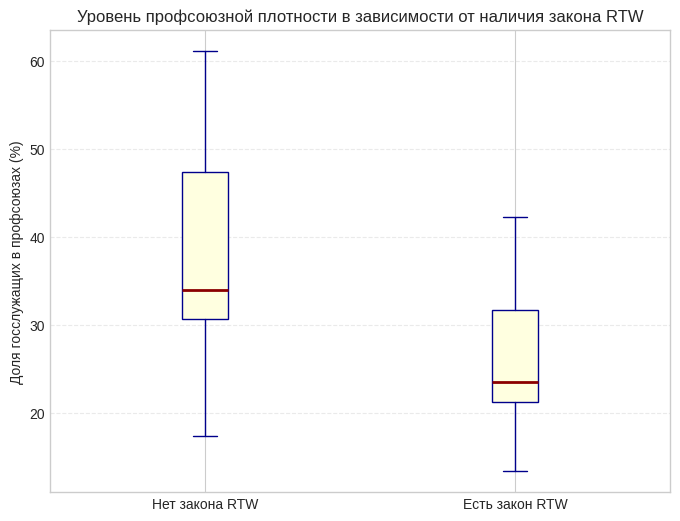

In [27]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(
    [dens_no_rtw, dens_has_rtw],
    patch_artist=True,
    tick_labels=['Нет закона RTW', 'Есть закон RTW'],
    boxprops=dict(facecolor='lightyellow', color='darkblue'),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    medianprops=dict(color='darkred', linewidth=2)
)
plt.title('Уровень профсоюзной плотности в зависимости от наличия закона RTW')
plt.ylabel('Доля госслужащих в профсоюзах (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

В штатах, где принят этот закон (разрешающий работать без вступления в профсоюз), процент муниципальных служащих в профсоюзах систематически ниже. Это соответствует логике: когда у работников есть выбор не вступать в профсоюз и не платить взносы, многие этим пользуются.